<a href="https://colab.research.google.com/github/akashgardas/freight-rail-delay-prediction/blob/model-building/notebooks/model_building/Random_Forest_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Regressor Model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
path = '/content/drive/MyDrive/CVR College/Mini Project/data/Finalized data/preprocessed_data.csv'

## Load

In [ ]:
df = pd.read_csv(path)
df.head()

,arrival_delay_time,teu_count,train_length,total_distance_trip,departure_delay_time,weight_per_length,weight_per_wagon
0,0,0.0,420.0,364,0,990.0,18900.0
1,0,0.0,420.0,364,0,990.0,18900.0
2,0,0.0,420.0,364,0,990.0,18900.0
3,0,0.0,420.0,364,0,990.0,18900.0
4,0,0.0,420.0,364,0,990.0,18900.0


In [ ]:
df.columns

Index(['arrival_delay_time', 'teu_count', 'train_length',
       'total_distance_trip', 'departure_delay_time', 'weight_per_length',
       'weight_per_wagon'],
      dtype='object')

## Feature Separation

In [ ]:
target_col = 'arrival_delay_time'

X = df.drop(columns=[target_col])
y = df[target_col]

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (61539, 6)
Target (y) shape: (61539,)


## Train Test Split

In [ ]:
# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 43077
Testing samples: 18462


## Build Model

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

## Evaluation

In [ ]:
# Predict delay times on the unseen test set
y_pred = rf_model.predict(X_test)

# Calculate error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Random Forest Evaluation ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE):      {mae:.2f}")
print(f"R-squared Score (R2):           {r2:.4f}")

--- Random Forest Evaluation ---
Root Mean Squared Error (RMSE): 27.98
Mean Absolute Error (MAE):      15.91
R-squared Score (R2):           0.2813


## Feature Importance

/tmp/ipykernel_9233/2561742999.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")


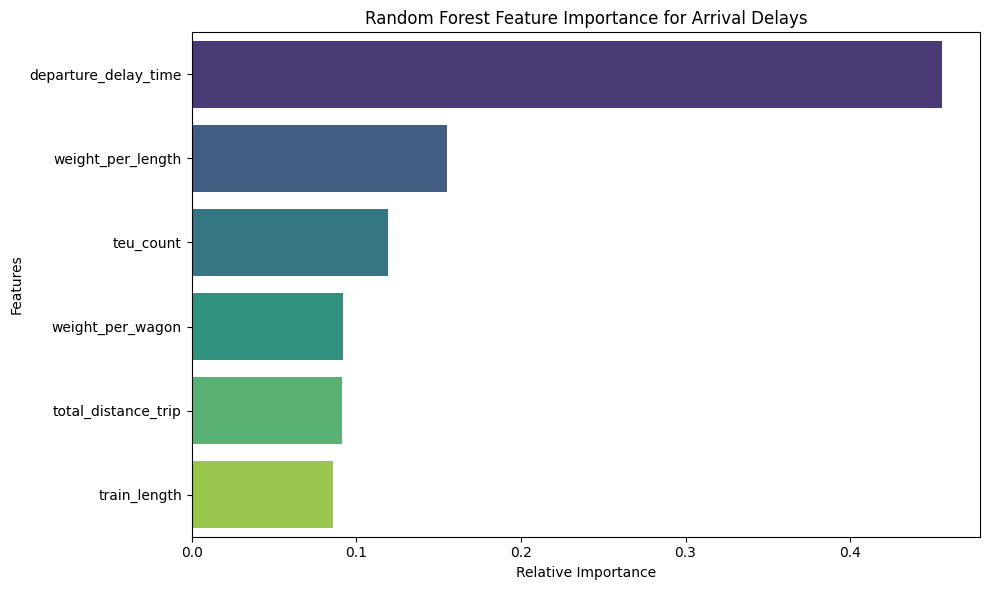

In [ ]:
# Extract feature importances from the trained model
importances = rf_model.feature_importances_
feature_names = X.columns

# Sort them in descending order
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")
plt.title('Random Forest Feature Importance for Arrival Delays')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## Export Model

In [ ]:
# Export model
import joblib

# Export the model to a file
joblib.dump(rf_model, 'random_forest_regressor.joblib')

# --- To load it back later ---
# loaded_model = joblib.load('my_model.joblib')

['random_forest_regressor.joblib']